In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Load client and price data
clean_data = pd.read_csv(r"C:\Users\khush\Desktop\K - Projects\BGC group\Data Science\Task files'\clean_data_after_eda.csv")
print(clean_data.head())

                                 id                     channel_sales  \
0  24011ae4ebbe3035111d65fa7c15bc57  foosdfpfkusacimwkcsosbicdxkicaua   
1  d29c2c54acc38ff3c0614d0a653813dd                           MISSING   
2  764c75f661154dac3a6c254cd082ea7d  foosdfpfkusacimwkcsosbicdxkicaua   
3  bba03439a292a1e166f80264c16191cb  lmkebamcaaclubfxadlmueccxoimlema   
4  149d57cf92fc41cf94415803a877cb4b                           MISSING   

   cons_12m  cons_gas_12m  cons_last_month  date_activ    date_end  \
0         0         54946                0  2013-06-15  2016-06-15   
1      4660             0                0  2009-08-21  2016-08-30   
2       544             0                0  2010-04-16  2016-04-16   
3      1584             0                0  2010-03-30  2016-03-30   
4      4425             0              526  2010-01-13  2016-03-07   

  date_modif_prod date_renewal  forecast_cons_12m  ...  \
0      2015-11-01   2015-06-23               0.00  ...   
1      2009-08-21   2015

In [ ]:
clean_data.describe()

In [ ]:
clean_data.isnull().mean()*100

In [ ]:
import pandas as pd
# Convert date column to datetime and extract useful date features
clean_data['price_date'] = pd.to_datetime(clean_data['date_activ'], format='%Y-%m-%d')
clean_data['year'] = clean_data['price_date'].dt.year
clean_data['month'] = clean_data['price_date'].dt.month
clean_data['day_of_week'] = clean_data['price_date'].dt.weekday


Missing Values Percentage:
 id                    0.0
price_date            0.0
price_off_peak_var    0.0
price_peak_var        0.0
price_mid_peak_var    0.0
price_off_peak_fix    0.0
price_peak_fix        0.0
price_mid_peak_fix    0.0
year                  0.0
month                 0.0
day_of_week           0.0
dtype: float64
Summary Statistics:
                           price_date  price_off_peak_var  price_peak_var  \
count                         193002       193002.000000   193002.000000   
mean   2015-06-16 12:50:49.933161216            0.141027        0.054630   
min              2015-01-01 00:00:00            0.000000        0.000000   
25%              2015-04-01 00:00:00            0.125976        0.000000   
50%              2015-07-01 00:00:00            0.146033        0.085483   
75%              2015-10-01 00:00:00            0.151635        0.101673   
max              2015-12-01 00:00:00            0.280700        0.229788   
std                              NaN      

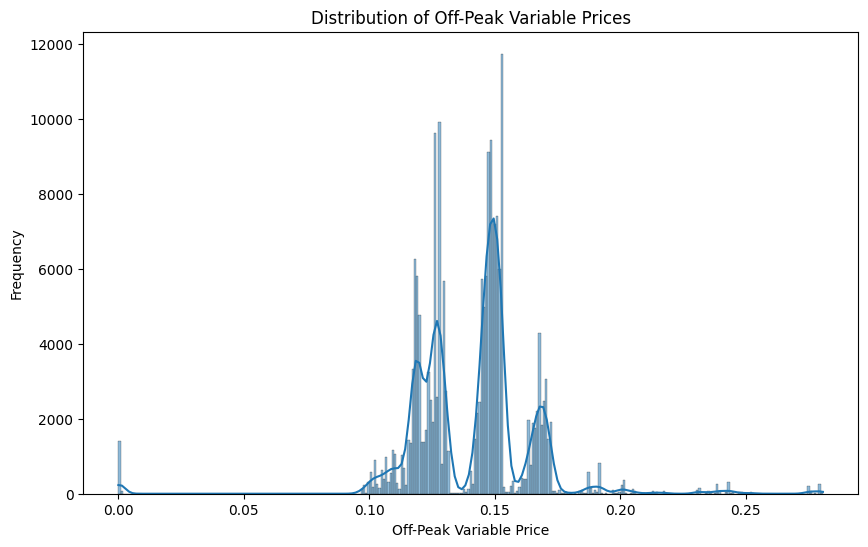

                                 id price_date  price_off_peak_var  \
0  038af19179925da21a25619c5a24b745 2015-01-01            0.151367   
1  038af19179925da21a25619c5a24b745 2015-02-01            0.151367   
2  038af19179925da21a25619c5a24b745 2015-03-01            0.151367   
3  038af19179925da21a25619c5a24b745 2015-04-01            0.149626   
4  038af19179925da21a25619c5a24b745 2015-05-01            0.149626   

   price_peak_var  price_mid_peak_var  price_off_peak_fix  price_peak_fix  \
0             0.0                 0.0           44.266931             0.0   
1             0.0                 0.0           44.266931             0.0   
2             0.0                 0.0           44.266931             0.0   
3             0.0                 0.0           44.266931             0.0   
4             0.0                 0.0           44.266931             0.0   

   price_mid_peak_fix  year  month  day_of_week  interaction_peak_midpeak  \
0                 0.0  2015      1     

ValueError: 
All the 324 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
324 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\khush\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\khush\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\khush\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py", line 421, in fit
    y, expanded_class_weight = self._validate_y_class_weight(y)
                               ^

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt

# Step 1: Data Loading
pricing_data = pd.read_csv(r"C:\Users\khush\Desktop\K - Projects\BGC group\Data Science\Task files'\pricing_data.csv")

# Step 2: Data Preprocessing
# Convert date columns to datetime and extract useful date features
pricing_data['price_date'] = pd.to_datetime(pricing_data['price_date'], format='%Y-%m-%d')
pricing_data['year'] = pricing_data['price_date'].dt.year
pricing_data['month'] = pricing_data['price_date'].dt.month
pricing_data['day_of_week'] = pricing_data['price_date'].dt.weekday

# Check for missing values
missing_values_pricing = pricing_data.isnull().mean() * 100
print("Missing Values Percentage:\n", missing_values_pricing)

# Step 3: Exploratory Data Analysis (EDA)
# Summary statistics
summary_stats_pricing = pricing_data.describe()
print("Summary Statistics:\n", summary_stats_pricing)

# Visualize the distribution of prices
plt.figure(figsize=(10, 6))
sns.histplot(pricing_data['price_off_peak_var'], kde=True)
plt.title('Distribution of Off-Peak Variable Prices')
plt.xlabel('Off-Peak Variable Price')
plt.ylabel('Frequency')
plt.show()

# Step 4: Feature Engineering
# Add interaction terms for further feature engineering
pricing_data['interaction_peak_midpeak'] = pricing_data['price_peak_var'] * pricing_data['price_mid_peak_var']
pricing_data['ratio_peak_midpeak'] = pricing_data['price_peak_var'] / (pricing_data['price_mid_peak_var'] + 1)  # Avoid division by zero

# Check the dataset after adding new features
print(pricing_data.head())

# Step 5: Data Splitting
# Prepare the data for modeling
X = pricing_data[['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var', 'interaction_peak_midpeak', 'ratio_peak_midpeak']]
y = pricing_data['price_off_peak_fix']  # Replace with the actual target variable if different

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Model Training
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 7: Model Evaluation
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

# Step 8: Model Optimization
# Hyperparameter tuning can be done using GridSearchCV or RandomizedSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred_best = best_model.predict(X_test)

# Evaluate the best model
print("Best Model Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Best Model Classification Report:\n", classification_report(y_test, y_pred_best))

In [ ]:

# Add interaction terms for further feature engineering
clean_data['interaction_energy_power'] = clean_data['var_year_price_off_peak_var'] * clean_data['var_year_price_off_peak_fix']
clean_data['ratio_energy_power'] = clean_data['var_year_price_off_peak_var'] / (clean_data['var_year_price_off_peak_fix'] + 1)  # Avoid division by zero

# Check the dataset after adding new features
clean_data.head()


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the data
clean_data = pd.read_csv(r"C:\Users\khush\Desktop\K - Projects\BGC group\Data Science\Task files'\customer_data.csv")  # Update the file path here

# Data Cleaning and Preprocessing
# Convert date column to datetime and extract useful date features
clean_data['price_date'] = pd.to_datetime(clean_data['date_activ'], format='%Y-%m-%d')
clean_data['year'] = clean_data['price_date'].dt.year
clean_data['month'] = clean_data['price_date'].dt.month
clean_data['day_of_week'] = clean_data['price_date'].dt.weekday

# Check for missing values
missing_values = clean_data.isnull().mean() * 100
print("Missing Values Percentage:\n", missing_values)

# Exploratory Data Analysis (EDA)
# Summary statistics
summary_stats = clean_data.describe()
print("Summary Statistics:\n", summary_stats)


# Feature Engineering
# Add interaction terms for further feature engineering
clean_data['interaction_energy_power'] = clean_data['var_year_price_off_peak_var'] * clean_data['var_year_price_off_peak_fix']
clean_data['ratio_energy_power'] = clean_data['var_year_price_off_peak_var'] / (clean_data['var_year_price_off_peak_fix'] + 1)  # Avoid division by zero

# Group off-peak prices by companies and month
monthly_price_by_id = clean_data.groupby(['id', 'price_date']).agg({
    'var_year_price_off_peak_var': 'mean',
    'var_year_price_off_peak_fix': 'mean'  
}).reset_index()

# Get January and December prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference between December and January prices
diff = pd.merge(
    dec_prices.rename(columns={
        'var_year_price_off_peak_var': 'dec_var', 
        'var_year_price_off_peak_fix': 'dec_fix'
    }), 
    jan_prices.rename(columns={
        'var_year_price_off_peak_var': 'jan_var', 
        'var_year_price_off_peak_fix': 'jan_fix'
    }).drop(columns='price_date'), 
    on='id'
)

# Compute the differences for both variable and fixed off-peak prices
diff['offpeak_diff_energy'] = diff['dec_var'] - diff['jan_var']
diff['offpeak_diff_power'] = diff['dec_fix'] - diff['jan_fix']

# Select the relevant columns
diff = diff[['id', 'offpeak_diff_energy', 'offpeak_diff_power']]
print(diff.head())

# Model Building and Evaluation (Example using Linear Regression)

# Prepare the data for modeling
X = clean_data[['var_year_price_off_peak_var', 'var_year_price_off_peak_fix', 'interaction_energy_power', 'ratio_energy_power']]
y = clean_data['target_variable']  # Replace 'target_variable' with the actual target variable name

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Missing Values Percentage:
 id                                0.0
channel_sales                     0.0
cons_12m                          0.0
cons_gas_12m                      0.0
cons_last_month                   0.0
date_activ                        0.0
date_end                          0.0
date_modif_prod                   0.0
date_renewal                      0.0
forecast_cons_12m                 0.0
forecast_cons_year                0.0
forecast_discount_energy          0.0
forecast_meter_rent_12m           0.0
forecast_price_energy_off_peak    0.0
forecast_price_energy_peak        0.0
forecast_price_pow_off_peak       0.0
has_gas                           0.0
imp_cons                          0.0
margin_gross_pow_ele              0.0
margin_net_pow_ele                0.0
nb_prod_act                       0.0
net_margin                        0.0
num_years_antig                   0.0
origin_up                         0.0
pow_max                           0.0
churn                 

KeyError: 'var_year_price_off_peak_var'

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# Step 1: Data Loading and Preprocessing
import matplotlib.pyplot as plt

# Load the data
customer_data = pd.read_csv(r"C:\Users\khush\Desktop\K - Projects\BGC group\Data Science\Task files'\customer_data.csv")
pricing_data = pd.read_csv(r"C:\Users\khush\Desktop\K - Projects\BGC group\Data Science\Task files'\pricing_data.csv")

# Convert date columns to datetime and extract useful date features
customer_data['price_date'] = pd.to_datetime(customer_data['date_activ'], format='%Y-%m-%d')
customer_data['year'] = customer_data['price_date'].dt.year
customer_data['month'] = customer_data['price_date'].dt.month
customer_data['day_of_week'] = customer_data['price_date'].dt.weekday

pricing_data['price_date'] = pd.to_datetime(pricing_data['price_date'], format='%Y-%m-%d')
pricing_data['year'] = pricing_data['price_date'].dt.year
pricing_data['month'] = pricing_data['price_date'].dt.month
pricing_data['day_of_week'] = pricing_data['price_date'].dt.weekday



# Compute the differences for both variable and fixed off-peak prices
diff['offpeak_diff_energy'] = diff['dec_var'] - diff['jan_var']
diff['offpeak_diff_power'] = diff['dec_fix'] - diff['jan_fix']

# Select the relevant columns
diff = diff[['id', 'offpeak_diff_energy', 'offpeak_diff_power']]
print(diff.head())

# Step 4: Model Building
# Prepare the data for modeling
X = customer_data[['cons_12m', 'cons_last_month', 'interaction_energy_power', 'ratio_energy_power']]
y = customer_data['churn']  # Replace 'churn' with the actual target variable name if different

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Step 5: Model Evaluation
# Evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Step 6: Model Tuning and Optimization
# Hyperparameter tuning can be done using GridSearchCV or RandomizedSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred_best = best_model.predict(X_test)

# Evaluate the best model
print("Best Model Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Best Model Classification Report:\n", classification_report(y_test, y_pred_best))

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt

# Step 1: Data Loading
pricing_data = pd.read_csv(r"C:\Users\khush\Desktop\K - Projects\BGC group\Data Science\Task files'\pricing_data.csv")

# Step 2: Data Preprocessing
# Convert date columns to datetime and extract useful date features
pricing_data['price_date'] = pd.to_datetime(pricing_data['price_date'], format='%Y-%m-%d')
pricing_data['year'] = pricing_data['price_date'].dt.year
pricing_data['month'] = pricing_data['price_date'].dt.month
pricing_data['day_of_week'] = pricing_data['price_date'].dt.weekday

# Check for missing values
missing_values_pricing = pricing_data.isnull().mean() * 100
print("Missing Values Percentage:\n", missing_values_pricing)

# Step 3: Exploratory Data Analysis (EDA)
# Summary statistics
summary_stats_pricing = pricing_data.describe()
print("Summary Statistics:\n", summary_stats_pricing)

# Visualize the distribution of prices
plt.figure(figsize=(10, 6))
sns.histplot(pricing_data['price_off_peak_var'], kde=True)
plt.title('Distribution of Off-Peak Variable Prices')
plt.xlabel('Off-Peak Variable Price')
plt.ylabel('Frequency')
plt.show()

# Step 4: Feature Engineering
# Add interaction terms for further feature engineering
pricing_data['interaction_peak_midpeak'] = pricing_data['price_peak_var'] * pricing_data['price_mid_peak_var']
pricing_data['ratio_peak_midpeak'] = pricing_data['price_peak_var'] / (pricing_data['price_mid_peak_var'] + 1)  # Avoid division by zero

# Check the dataset after adding new features
print(pricing_data.head())

# Step 5: Data Splitting
# Prepare the data for modeling
X = pricing_data[['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var', 'interaction_peak_midpeak', 'ratio_peak_midpeak']]
y = pricing_data['price_off_peak_fix']  # Replace with the actual target variable if different

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Model Training
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 7: Model Evaluation
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

# Step 8: Model Optimization
# Hyperparameter tuning can be done using GridSearchCV or RandomizedSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Get the best parameters and best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred_best = best_model.predict(X_test)

# Evaluate the best model
print("Best Model Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Best Model Classification Report:\n", classification_report(y_test, y_pred_best))

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(r"C:\Users\khush\Desktop\K - Projects\BGC group\Data Science\Task files'\clean_data_after_eda.csv")

# Display basic info
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

# Ensure date columns are in datetime format
date_columns = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Step 2: Feature Engineering from Date Columns
# Tenure in days
df['tenure_days'] = (df['date_end'] - df['date_activ']).dt.days

# Days since last modification
df['days_since_modif'] = (df['date_end'] - df['date_modif_prod']).dt.days

# Days until renewal
df['days_until_renewal'] = (df['date_renewal'] - df['date_end']).dt.days

# Step 3: Price Difference Features
# Aggregate prices by ID (assuming multiple entries per ID are not present in this clean data)
price_cols = ['forecast_price_energy_off_peak', 'forecast_price_energy_peak', 'forecast_price_pow_off_peak']
for col in price_cols:
    df[f'{col}_diff'] = df[col] - df[col].shift(1)  # Simplified difference; assumes single entry per ID

# Step 4: Interaction and Ratio Features
# Interaction between off-peak and peak energy prices
df['energy_price_interaction'] = df['forecast_price_energy_off_peak'] * df['forecast_price_energy_peak']

# Ratio of off-peak to power price
df['off_peak_to_power_ratio'] = df['forecast_price_energy_off_peak'] / df['forecast_price_pow_off_peak'].replace(0, np.nan)

# Step 5: Log Transformation for Skewed Features
numerical_cols = ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'forecast_cons_12m', 'net_margin', 'pow_max']
for col in numerical_cols:
    if df[col].min() > 0:  # Ensure no zero or negative values
        df[f'{col}_log'] = np.log1p(df[col])
    else:
        df[f'{col}_log'] = np.log1p(df[col] + abs(df[col].min()) + 1)  # Shift to positive

# Step 6: Categorical Encoding
# One-Hot Encoding for nominal variables
categorical_cols = ['channel_sales', 'origin_up']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Label Encoding for binary variable
le = LabelEncoder()
df_encoded['has_gas'] = le.fit_transform(df_encoded['has_gas'])

# Step 7: Visualizations
# Distribution Plots
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
sns.histplot(df_encoded['tenure_days'].dropna(), bins=30, kde=True)
plt.title('Distribution of Tenure Days')
plt.subplot(2, 1, 2)
sns.histplot(df_encoded['forecast_price_energy_off_peak_diff'].dropna(), bins=30, kde=True)
plt.title('Distribution of Off-Peak Price Difference')
plt.tight_layout()
plt.savefig('distributions.png')
plt.close()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.close()

# Step 8: Save the Enhanced Dataset
df_encoded.to_csv('enhanced_data.csv', index=False)
print("\nEnhanced dataset saved as 'enhanced_data.csv'")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_ren